=== Training Results ===
Input: [0 0] | Predicted: 0.0009 | Target: 0
Input: [0 1] | Predicted: 0.9984 | Target: 1
Input: [1 0] | Predicted: 0.9975 | Target: 1
Input: [1 1] | Predicted: 0.0030 | Target: 0


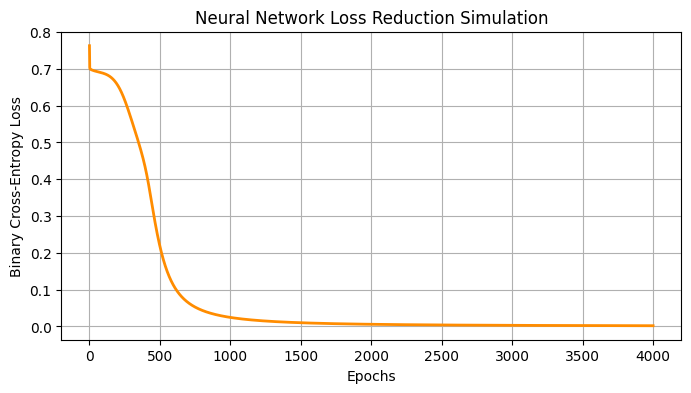

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# 1. Activation functions and derivatives
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)


# 2. Neural Network Class
class NeuralNetworkFromScratch:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.5):
        np.random.seed(42)
        # Initialize Weights and Biases
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output):
        m = X.shape[0]

        # Output layer error
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer error (Chain Rule)
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * sigmoid_derivative(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update Parameters
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def compute_loss(self, y, output):
        return -np.mean(
            y * np.log(output + 1e-15) + (1 - y) * np.log(1 - output + 1e-15)
        )


# 3. Execution & Simulation
if __name__ == "__main__":
    # XOR Dataset
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y = np.array([[0], [1], [1], [0]])

    nn = NeuralNetworkFromScratch(
        input_size=2, hidden_size=4, output_size=1, learning_rate=0.8
    )

    losses = []
    epochs = 4000

    for epoch in range(epochs):
        output = nn.forward(X)
        loss = nn.compute_loss(y, output)
        losses.append(loss)
        nn.backward(X, y, output)

    print("=== Training Results ===")
    predictions = nn.forward(X)
    for i in range(len(X)):
        print(f"Input: {X[i]} | Predicted: {predictions[i][0]:.4f} | Target: {y[i][0]}")

    plt.figure(figsize=(8, 4))
    plt.plot(losses, color="darkorange", linewidth=2)
    plt.title("Neural Network Loss Reduction Simulation")
    plt.xlabel("Epochs")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.grid(True)
